# Geo-FNO FFT/IFFT Roundtrip Diagnostic

Goal: test whether spatial degradation (e.g., right-half artifacts) is already introduced by the mesh-free spectral transform itself.

This notebook applies the same `SpectralConv2d` mesh-free Fourier machinery in an identity roundtrip (spectral encode/decode) to an initial field, then compares:
1. original field
2. roundtrip without IPHI mapping
3. roundtrip with IPHI mapping (optional)

If artifacts already appear here, the issue is in representation/mapping/spectral truncation, not only in training optimization.


In [16]:
import os
import h5py
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.tri as tri

import torch.nn as nn
import torch.nn.functional as F

from geo_FNO_def import SpectralConv2d, get_global_L_from_h5

# ----------------------------
# Config
# ----------------------------
H5_PATH = "/scratch/mnhagen/datasets/incompressible_euler/test.h5"
sample_id = "sample_000034"
t_in = 0

# Field choice for roundtrip
# field_type: "ux", "uy", or "speed"
field_type = "ux"

# Use the same spectral/grid settings as a trained run you want to diagnose
modes1 = 24
modes2 = 12
s1 = 100
s2 = 25

# Optional: load a trained IPHI mapping for mapped roundtrip
USE_IPHI = True
IPHI_CKPT = "/scratch/mnhagen/models/geofno/cylinder_vel_t0_t-1_with_node_type_asymmetrical_iphi.pt"

boundary_label = 6
band_frac = 0.06

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("device:", device)



device: cuda:0


In [17]:
class IPHI(nn.Module):
    """
    Local diagnostic IPHI copy.
    Same architecture as geo_FNO_def.IPHI, but mapping output is x + h
    instead of x + x*h for targeted ablation.
    """
    def __init__(self, width=32, device="cuda:0"):
        super().__init__()
        self.width = width

        self.raw_dim = 5  # [x, y, sin(angle), cos(angle), radius]
        self.freq_dim = self.raw_dim * (self.width // 4)
        self.feat_dim = self.width + 2 * self.freq_dim

        self.fc0 = nn.Linear(self.raw_dim, self.width)
        self.fc_code = nn.Linear(42, self.width)

        self.fc_no_code = nn.Linear(self.feat_dim, 4 * self.width)
        self.fc1 = nn.Linear(self.width + self.feat_dim, 4 * self.width)

        self.fc2 = nn.Linear(4 * self.width, 4 * self.width)
        self.fc3 = nn.Linear(4 * self.width, 2)
        nn.init.zeros_(self.fc3.weight)
        nn.init.zeros_(self.fc3.bias)

        self.B = np.pi * torch.pow(
            2, torch.arange(0, self.width // 4, dtype=torch.float, device=device)
        ).reshape(1, 1, 1, self.width // 4)

    def forward(self, x, code=None):
        if code is not None:
            center = code[:, 0:2].unsqueeze(1)
        else:
            center = torch.tensor([0.5, 0.5], device=x.device, dtype=x.dtype).view(1, 1, 2).repeat(x.shape[0], 1, 1)

        dx = x[:, :, 0] - center[:, :, 0]
        dy = x[:, :, 1] - center[:, :, 1]
        angle = torch.atan2(dy, dx)
        radius = torch.norm(x - center, dim=-1, p=2)

        sin_a = torch.sin(angle)
        cos_a = torch.cos(angle)
        xd = torch.stack([x[:, :, 0], x[:, :, 1], sin_a, cos_a, radius], dim=-1)

        b, n, d = xd.shape
        x_sin = torch.sin(self.B * xd.view(b, n, d, 1)).view(b, n, d * self.width // 4)
        x_cos = torch.cos(self.B * xd.view(b, n, d, 1)).view(b, n, d * self.width // 4)

        xd0 = self.fc0(xd)
        feat = torch.cat([xd0, x_sin, x_cos], dim=-1)

        if code is not None:
            cd = self.fc_code(code).unsqueeze(1).repeat(1, n, 1)
            h_in = torch.cat([cd, feat], dim=-1)
            h = F.gelu(self.fc1(h_in))
        else:
            h = F.gelu(self.fc_no_code(feat))

        h = F.gelu(self.fc2(h))
        h = self.fc3(h)

        # Ablation under test: additive mapping, no coordinate scaling.
        return x + torch.tanh(h)


# ----------------------------
# Utilities
# ----------------------------
def fit_circle_kasa(x: np.ndarray, y: np.ndarray):
    A = np.stack([x, y, np.ones_like(x)], axis=1)
    b = -(x**2 + y**2)
    sol, *_ = np.linalg.lstsq(A, b, rcond=None)
    a, b_, c = sol
    xc = -a / 2.0
    yc = -b_ / 2.0
    r2 = (a * a + b_ * b_) / 4.0 - c
    r = float(np.sqrt(max(r2, 0.0)))
    return float(xc), float(yc), float(r)


def estimate_cylinder_from_label6(pos: np.ndarray, node_type: np.ndarray,
                                  boundary_label: int = 6, band_frac: float = 0.06):
    xy = pos[node_type == boundary_label]
    y = xy[:, 1]
    ymin, ymax = float(y.min()), float(y.max())
    band = band_frac * (ymax - ymin)
    cyl_mask = (y > ymin + band) & (y < ymax - band)
    xy_cyl = xy[cyl_mask]
    xc, yc, r = fit_circle_kasa(xy_cyl[:, 0], xy_cyl[:, 1])
    return xc, yc, r


def make_identity_meshfree_roundtrip(modes1: int, modes2: int, s1: int, s2: int, L):
    """
    Build a SpectralConv2d configured as a near-identity spectral roundtrip:
    - no channel mixing (1 in, 1 out)
    - weights set to 1 on retained modes
    This isolates truncation/mapping effects from learned weights.
    """
    conv = SpectralConv2d(
        in_channels=1,
        out_channels=1,
        modes1=modes1,
        modes2=modes2,
        s1=s1,
        s2=s2,
        L=L,
    ).to(device)

    with torch.no_grad():
        conv.weights1.zero_()
        conv.weights2.zero_()
        conv.weights1[0, 0, :, :] = 1.0 + 0.0j
        conv.weights2[0, 0, :, :] = 1.0 + 0.0j

    conv.eval()
    return conv


def roundtrip_field(field_np: np.ndarray, pos_t: torch.Tensor, conv: SpectralConv2d,
                    iphi=None, code_t=None):
    # field_np: (N,)
    u_t = torch.from_numpy(field_np.astype(np.float32)).view(1, 1, -1).to(device)
    with torch.no_grad():
        out = conv(u_t, x_in=pos_t, x_out=pos_t, iphi=iphi, code=code_t)
    return out[0, 0].detach().cpu().numpy().astype(np.float32)



In [18]:
# ----------------------------
# Load one sample
# ----------------------------
with h5py.File(H5_PATH, "r") as f:
    g = f[sample_id]
    pos = g["pos"][:]                 # (N,2)
    cells_arr = g["cells"][:]         # (C,3)
    node_type = g["node_type"][:]     # (N,)
    vel = g["vel"][:]                 # (T,N,2)

u0 = vel[t_in].astype(np.float32)     # (N,2)

if field_type == "ux":
    field = u0[:, 0]
elif field_type == "uy":
    field = u0[:, 1]
elif field_type == "speed":
    field = np.linalg.norm(u0, axis=1)
else:
    raise ValueError(f"Unsupported field_type={field_type}")

triang = tri.Triangulation(pos[:, 0], pos[:, 1], cells_arr)
pos_t = torch.from_numpy(pos.astype(np.float32)).unsqueeze(0).to(device)

xc, yc, r = estimate_cylinder_from_label6(pos, node_type, boundary_label=boundary_label, band_frac=band_frac)
code42 = np.zeros((42,), dtype=np.float32)
code42[0], code42[1], code42[2] = xc, yc, r
code_t = torch.from_numpy(code42).unsqueeze(0).to(device)

L_global, key_used = get_global_L_from_h5(H5_PATH)
print("Using L_global from", key_used, ":", L_global)
print("sample:", sample_id, "field:", field_type)



Using L_global from sample_000000 : [1.600000023841858, 0.4099999964237213]
sample: sample_000034 field: ux


In [19]:
# ----------------------------
# Roundtrip without IPHI
# ----------------------------
conv = make_identity_meshfree_roundtrip(modes1=modes1, modes2=modes2, s1=s1, s2=s2, L=L_global)
field_rt_nomap = roundtrip_field(field, pos_t, conv, iphi=None, code_t=None)

# ----------------------------
# Roundtrip with local IPHI x+h (optional)
# ----------------------------
field_rt_iphi = None
iphi_model = None

if USE_IPHI and os.path.exists(IPHI_CKPT):
    iphi_model = IPHI(width=32, device=str(device)).to(device)
    iphi_model.load_state_dict(torch.load(IPHI_CKPT, map_location=device), strict=False)
    iphi_model.eval()
    field_rt_iphi = roundtrip_field(field, pos_t, conv, iphi=iphi_model, code_t=code_t)
    print("Loaded IPHI checkpoint:", IPHI_CKPT)
elif USE_IPHI:
    print("USE_IPHI=True but checkpoint not found. Skipping mapped roundtrip.")



Loaded IPHI checkpoint: /scratch/mnhagen/models/geofno/cylinder_vel_t0_t-1_with_node_type_asymmetrical_iphi.pt


No-IPHI roundtrip relRMSE: 3.744698e+03
No-IPHI | MAE left=6.631e+02 right=4.549e+02 right/left=0.686
With-IPHI roundtrip relRMSE: 4.204393e+03
With-IPHI | MAE left=7.103e+02 right=6.523e+02 right/left=0.918


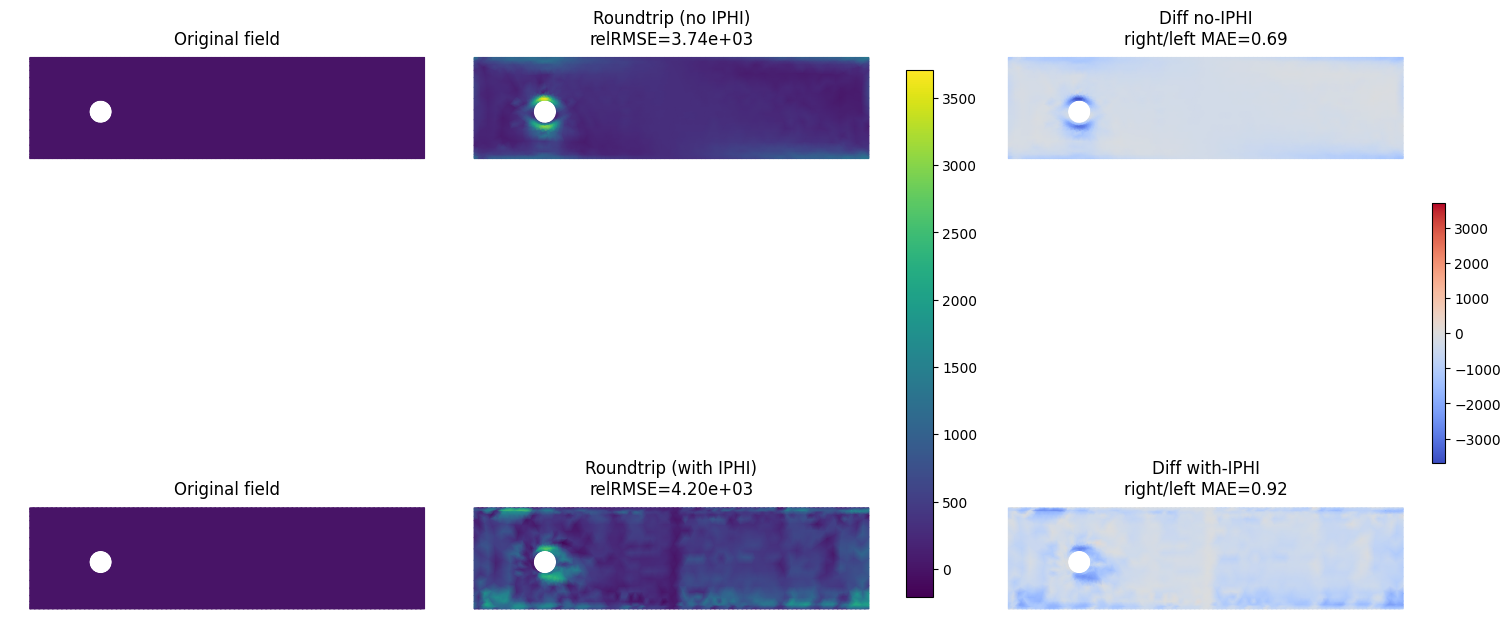

In [20]:
# ----------------------------
# Metrics + plots
# ----------------------------
def rel_l2(a, b, eps=1e-12):
    num = np.sqrt(np.mean((a - b) ** 2))
    den = np.sqrt(max(np.mean(b ** 2), eps))
    return float(num / den)


def left_right_mae(diff, xcoord):
    xm = 0.5 * (float(xcoord.min()) + float(xcoord.max()))
    left = np.abs(diff[xcoord <= xm]).mean()
    right = np.abs(diff[xcoord > xm]).mean()
    return float(left), float(right), float(right / max(left, 1e-12))


diff_nomap = field - field_rt_nomap
rel_nomap = rel_l2(field_rt_nomap, field)
left_nomap, right_nomap, ratio_nomap = left_right_mae(diff_nomap, pos[:, 0])

print(f"No-IPHI roundtrip relRMSE: {rel_nomap:.6e}")
print(f"No-IPHI | MAE left={left_nomap:.3e} right={right_nomap:.3e} right/left={ratio_nomap:.3f}")

if field_rt_iphi is not None:
    diff_iphi = field - field_rt_iphi
    rel_iphi = rel_l2(field_rt_iphi, field)
    left_iphi, right_iphi, ratio_iphi = left_right_mae(diff_iphi, pos[:, 0])
    print(f"With-IPHI roundtrip relRMSE: {rel_iphi:.6e}")
    print(f"With-IPHI | MAE left={left_iphi:.3e} right={right_iphi:.3e} right/left={ratio_iphi:.3f}")

vmin = float(min(field.min(), field_rt_nomap.min(), field_rt_iphi.min() if field_rt_iphi is not None else field_rt_nomap.min()))
vmax = float(max(field.max(), field_rt_nomap.max(), field_rt_iphi.max() if field_rt_iphi is not None else field_rt_nomap.max()))

if field_rt_iphi is None:
    dabs = float(np.max(np.abs(diff_nomap)))
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), constrained_layout=True)

    im0 = axes[0].tripcolor(triang, field, shading="gouraud", vmin=vmin, vmax=vmax)
    axes[0].set_title("Original field")
    axes[0].set_aspect("equal")
    axes[0].axis("off")

    im1 = axes[1].tripcolor(triang, field_rt_nomap, shading="gouraud", vmin=vmin, vmax=vmax)
    axes[1].set_title(f"Roundtrip (no IPHI)\nrelRMSE={rel_nomap:.2e}")
    axes[1].set_aspect("equal")
    axes[1].axis("off")

    im2 = axes[2].tripcolor(triang, diff_nomap, shading="gouraud", cmap="coolwarm", vmin=-dabs, vmax=dabs)
    axes[2].set_title(f"Diff (orig - roundtrip)\nright/left MAE={ratio_nomap:.2f}")
    axes[2].set_aspect("equal")
    axes[2].axis("off")

    fig.colorbar(im1, ax=axes[:2], fraction=0.03, pad=0.02)
    fig.colorbar(im2, ax=axes[2], fraction=0.03, pad=0.02)
    plt.show()
else:
    diff_iphi = field - field_rt_iphi
    dabs = float(max(np.max(np.abs(diff_nomap)), np.max(np.abs(diff_iphi))))

    fig, axes = plt.subplots(2, 3, figsize=(15, 9), constrained_layout=True)

    im00 = axes[0, 0].tripcolor(triang, field, shading="gouraud", vmin=vmin, vmax=vmax)
    axes[0, 0].set_title("Original field")
    axes[0, 0].set_aspect("equal")
    axes[0, 0].axis("off")

    im01 = axes[0, 1].tripcolor(triang, field_rt_nomap, shading="gouraud", vmin=vmin, vmax=vmax)
    axes[0, 1].set_title(f"Roundtrip (no IPHI)\nrelRMSE={rel_nomap:.2e}")
    axes[0, 1].set_aspect("equal")
    axes[0, 1].axis("off")

    im02 = axes[0, 2].tripcolor(triang, diff_nomap, shading="gouraud", cmap="coolwarm", vmin=-dabs, vmax=dabs)
    axes[0, 2].set_title(f"Diff no-IPHI\nright/left MAE={ratio_nomap:.2f}")
    axes[0, 2].set_aspect("equal")
    axes[0, 2].axis("off")

    im10 = axes[1, 0].tripcolor(triang, field, shading="gouraud", vmin=vmin, vmax=vmax)
    axes[1, 0].set_title("Original field")
    axes[1, 0].set_aspect("equal")
    axes[1, 0].axis("off")

    im11 = axes[1, 1].tripcolor(triang, field_rt_iphi, shading="gouraud", vmin=vmin, vmax=vmax)
    axes[1, 1].set_title(f"Roundtrip (with IPHI)\nrelRMSE={rel_iphi:.2e}")
    axes[1, 1].set_aspect("equal")
    axes[1, 1].axis("off")

    im12 = axes[1, 2].tripcolor(triang, diff_iphi, shading="gouraud", cmap="coolwarm", vmin=-dabs, vmax=dabs)
    axes[1, 2].set_title(f"Diff with-IPHI\nright/left MAE={ratio_iphi:.2f}")
    axes[1, 2].set_aspect("equal")
    axes[1, 2].axis("off")

    fig.colorbar(im01, ax=[axes[0, 0], axes[0, 1], axes[1, 0], axes[1, 1]], fraction=0.03, pad=0.02)
    fig.colorbar(im12, ax=[axes[0, 2], axes[1, 2]], fraction=0.03, pad=0.02)
    plt.show()



## How To Interpret
- If no-IPHI roundtrip already shows strong right-half error (`right/left MAE >> 1`), the issue is mostly spectral representation/discretization settings (`modes1/modes2/s1/s2`, sampling, interpolation).
- If no-IPHI looks fine but with-IPHI introduces right-half degradation, mapping (`IPHI`) is likely the culprit.
- If both roundtrips look fine but trained model still fails, the issue is more likely optimization/data/model-capacity, not the raw FFT/IFFT machinery.
